In [4]:
import psycopg2
from psycopg2 import sql

conn = psycopg2.connect(dbname='wikidata_change_classification', user='postgres', password='postgres', host='172.16.64.23', port='5432')

queries = [
    ("Number of files", 
     "SELECT COUNT(distinct file_path) FROM revision"),

    ("Number of changes", 
     "SELECT COUNT(*) FROM value_change"),
    
    ("Number of creates", 
     "SELECT COUNT(*) FROM value_change WHERE action = 'CREATE'"),

    ("Number of deletes", 
     "SELECT COUNT(*) FROM value_change WHERE action = 'DELETE'"),

    ("Number of updates", 
     "SELECT COUNT(*) FROM value_change WHERE action = 'UPDATE'"),
    
    ("Number of value updates", 
     "SELECT COUNT(*) FROM value_change WHERE action = 'UPDATE' AND change_target = ''"),
    
    ("Number of string updates", 
     """SELECT COUNT(*) FROM value_change 
        WHERE action = 'UPDATE' AND change_target = '' 
        AND datatype IN ('monolingualtext', 'string', 'external-id', 'url', 'commonsMedia', 
                         'geo-shape', 'tabular-data', 'math', 'musical-notation', 'unknown-values')"""),
    
    ("Number of entity updates", 
     """SELECT COUNT(*) FROM value_change 
        WHERE action = 'UPDATE' AND change_target = '' 
        AND datatype IN ('wikibase-item', 'wikibase-entityid', 'wikibase-property', 
                         'wikibase-lexeme', 'wikibase-sense', 'wikibase-form', 'entity-schema')"""),

    ("Number of quantity updates", 
     "SELECT COUNT(*) FROM value_change WHERE action = 'UPDATE' AND change_target = '' AND datatype = 'quantity'"),
    
    ("Number of time updates", 
     "SELECT COUNT(*) FROM value_change WHERE action = 'UPDATE' AND change_target = '' AND datatype = 'time'"),
    
    ("Number of globecoordinate updates", 
     "SELECT COUNT(*) FROM value_change WHERE action = 'UPDATE' AND change_target = '' AND datatype = 'globecoordinate'"),

    ("Number of rank updates", 
     "SELECT COUNT(*) FROM value_change WHERE action = 'UPDATE' AND change_target = 'rank'"),

    ("Number of rank creations", 
     "SELECT COUNT(*) FROM value_change WHERE action = 'CREATE' AND change_target = 'rank'"),

    ("Number of rank deletions", 
     "SELECT COUNT(*) FROM value_change WHERE action = 'DELETE' AND change_target = 'rank'"),
    
    ("Number of dt metadata updates", 
     "SELECT COUNT(*) FROM value_change WHERE action = 'UPDATE' AND change_target != 'rank' AND change_target != ''"),

    ("Number of dt metadata creations", 
     "SELECT COUNT(*) FROM value_change WHERE action = 'CREATE' AND change_target != 'rank' AND change_target != ''"),

    ("Number of dt metadata deletions", 
     "SELECT COUNT(*) FROM value_change WHERE action = 'DELETE' AND change_target != 'rank' AND change_target != ''"),
    
]

print("="*70)
print("DATABASE STATISTICS")
print("="*70)

try:
    cur = conn.cursor()
    
    for description, query in queries:
        cur.execute(query)
        result = cur.fetchone()[0]
        print(f"{description:.<50} {result:>15,}")
    
    cur.close()
    
except Exception as e:
    print(f"Error: {e}")
    
finally:
    conn.close()

print("="*70)


DATABASE STATISTICS
Number of files...................................             107
Number of changes.................................      59,641,183
Number of creates.................................      47,790,058
Number of deletes.................................       7,911,307
Number of updates.................................       3,939,818
Number of value updates...........................       2,760,666
Number of string updates..........................       1,550,206
Number of entity updates..........................         956,018
Number of quantity updates........................         121,727
Number of time updates............................         105,357
Number of globecoordinate updates.................          27,025
Number of rank updates............................         558,610
Number of rank creations..........................      21,151,877
Number of rank deletions..........................       3,457,076
Number of dt metadata updates.............

In [15]:
# remove duplicate changes
import pandas as pd 
df = pd.read_csv('../gold_standard.csv')
print('Before droping duplicates:', len(df.index))

df = df.drop_duplicates(subset=['new_value', 'old_value'])
print('After droping duplicates:', len(df.index))

df.to_csv('../gold_standard_deduplicated.csv', index=False)


Before droping duplicates: 4238
After droping duplicates: 4237


## Tagged changes distribution - Normal classes

In [ ]:
import pandas as pd

CHANGE_LABELS = ['textual_change', 're-formatting', 'refinement', 'unrefinement', 'property_value_update', 'link_fix', 'property_replacement', 'rewording', 'reverted_edit', 'rank_deprecation']

df = pd.read_csv('gold_standard/gold_standard.csv')

WD_STRING_TYPES = ['monolingualtext', 'string', 'external-id', 'url', 'commonsMedia', 'geo-shape', 'tabular-data', 'math', 'musical-notation', 'unknown-values']
WD_ENTITY_TYPES = ['wikibase-item', 'wikibase-entityid', 'wikibase-property', 'wikibase-lexeme', 'wikibase-sense', 'wikibase-form', 'entity-schema']

df['new_datatype'] = df['datatype'].apply(
    lambda x: 'text' if x in WD_STRING_TYPES else ('entity' if x in WD_ENTITY_TYPES else x)
)

df['label_list'] = df['label'].str.split(', ')

df_exploded = df.explode('label_list')

df_exploded['label_list'] = df_exploded['label_list'].str.strip()

counts = df_exploded.groupby(['new_datatype', 'label_list']).size().reset_index(name='count')

print("Counts by datatype and label:")
print(counts)

pivot = counts.pivot_table(
    index='new_datatype',
    columns='label_list',
    values='count',
    fill_value=0
)

print("\nTotal per label:")
total_per_label = counts.groupby('label_list')['count'].sum().sort_values(ascending=False)
print(total_per_label)

print('\nTOTAL: ', total_per_label.sum())

## Analyze features

In [ ]:
import pickle
import pandas as pd
import numpy as np

with open('datatype_classifiers_multilabel.pkl', 'rb') as f:
    classifiers = pickle.load(f)

for datatype, info in classifiers.items():
    
    # Get best fold
    highest_f1_score_micro = 0
    best_model_info = None

    for fold_info in info:
        if fold_info['f1_score_micro'] > highest_f1_score_micro:
            highest_f1_score_micro = fold_info['f1_score_micro']
            best_model_info = fold_info

    if best_model_info:
        print(f"\n{'='*80}")
        print(f"{datatype.upper()} - Best F1-micro: {highest_f1_score_micro:.3f}")
        print(f"{'='*80}")
        
        model = best_model_info['classifier']
        features = best_model_info['features']
        mlb = best_model_info['multi_label_binarizer']
        labels = mlb.classes_
        
        # For each label, show feature importance
        for i, label in enumerate(labels):
            print(f"\n{'─'*80}")
            print(f"LABEL: {label}")
            print(f"{'─'*80}")
            
            estimator = model.estimators_[i]
            importances = estimator.feature_importances_
            
            # Create DataFrame with feature names and importances
            feature_imp = pd.DataFrame({
                'Feature': features,
                'Importance': importances
            }).sort_values('Importance', ascending=False)
            
            # Show top 10 features
            print(feature_imp.head(10).to_string(index=False))
            
        # Also show average across all labels
        print(f"\n{'='*80}")
        print(f"AVERAGE FEATURE IMPORTANCE (across all labels for {datatype})")
        print(f"{'='*80}")
        
        all_importances = np.array([
            model.estimators_[i].feature_importances_ 
            for i in range(len(labels))
        ])
        avg_importance = all_importances.mean(axis=0)
        
        avg_feature_imp = pd.DataFrame({
            'Feature': features,
            'Avg_Importance': avg_importance
        }).sort_values('Avg_Importance', ascending=False)
        
        print(avg_feature_imp.head(10).to_string(index=False))

## Result analysis

In [ ]:
import pickle
import pandas as pd
import numpy as np

# TODO:
# features correlate with the labels
# see feature importance for the ones that don't perform that well


with open('datatype_classifiers_multilabel_kn.pkl', 'rb') as f:
    classifiers = pickle.load(f)

print(classifiers.keys())
for datatype, info in classifiers.items():
    print(f"\n{'='*80}")
    print(f"DATATYPE: {datatype.upper()}")
    print(f"{'='*80}")

    num_folds = len(info)

    overall_accuracy_all_folds = 0
    overall_precision_all_folds = 0
    overall_recall_all_folds = 0
    accuracy_per_label_all_folds = {label: 0 for label in info[0].get('accuracy_per_label', {}).keys()}
    precision_per_label_all_folds = {label: 0 for label in info[0].get('precision_per_label', {}).keys()}
    recall_per_label_all_folds = {label: 0 for label in info[0].get('recall_per_label', {}).keys()}
    label_distribution = info[0].get('label_distribution', {}) # it's the same for all folds
    features = info[0].get('features', [])

    for fold_info in info:
        accuracy_per_label = fold_info.get('accuracy_per_label', {})
        precision_per_label = fold_info.get('precision_per_label', {})
        recall_per_label = fold_info.get('recall_per_label', {})
        for label, acc in accuracy_per_label.items():
            accuracy_per_label_all_folds[label] += acc

        for label, prec in precision_per_label.items():
            precision_per_label_all_folds[label] += prec
        for label, rec in recall_per_label.items():
            recall_per_label_all_folds[label] += recall_per_label.get(label, 0)
        
        overall_accuracy_all_folds += fold_info.get('overall_accuracy', None)
        overall_precision_all_folds += fold_info.get('overall_precision', None)
        overall_recall_all_folds += fold_info.get('overall_recall', None)
        
    avg_overall_accuracy = overall_accuracy_all_folds/num_folds if overall_accuracy_all_folds else None
    avg_overall_precision = overall_precision_all_folds/num_folds if overall_precision_all_folds else None
    avg_overall_recall = overall_recall_all_folds/num_folds if overall_recall_all_folds else None

    for label, total_acc in accuracy_per_label_all_folds.items():
        accuracy_per_label_all_folds[label] = total_acc / num_folds
        precision_per_label_all_folds[label] = precision_per_label_all_folds[label] / num_folds
        recall_per_label_all_folds[label] = recall_per_label_all_folds[label] / num_folds
        print(f"LABEL: {label.upper()}")

        print(f"Avg. Accuracy': {accuracy_per_label_all_folds[label]:.3f}")
        print(f"Avg. Precision': {precision_per_label_all_folds[label]:.3f}")
        print(f"Avg. Recall': {recall_per_label_all_folds[label]:.3f}")

        print(f"{'-'*80}")
        

    if avg_overall_accuracy is not None:
        print(f"\nAvg. Overall Accuracy: {avg_overall_accuracy:.3f}")
    if avg_overall_precision is not None:
        print(f"Avg. Overall Precision: {avg_overall_precision:.3f}")
    if avg_overall_recall is not None:
        print(f"Avg. Overall Recall: {avg_overall_recall:.3f}")

    

    print(f"\nLabel Distribution:")
    for label, distribution in label_distribution.items():
        print(f"'{label}': {distribution}")
    
    print(f"\nFeatures: {features}")

In [103]:
import matplotlib.pyplot as plt
import numpy as np
import pickle

"""
"model": {
    "datatype":{
        "label": {
            "precision": float,
            "recall": float,
            "accuracy": float
        }
    }
}
"""

# Create data structure
results = {}
for model in ['kn', 'random_forest', 'gradient_boosting', 'xgboost']:
    print(f'Processing model: {model}')
    with open(f'classifiers_multilabel_{model}.pkl', 'rb') as f:
        classifiers = pickle.load(f)
    
    results[model] = {}
    
    # go over each fold's results for a single datatype
    for datatype, folds_info in classifiers.items():
        
        results[model][datatype] = {}
    
        overall_accuracy_all_folds = {}
        overall_precision_all_folds = {}
        overall_recall_all_folds = {}
        overall_f1_all_folds = {}

        num_folds = len(folds_info)

        for fold in folds_info:

            for label, metric_values in fold['metrics_results'].items(): # metric values for this fold
                
                if label not in overall_accuracy_all_folds:
                    overall_accuracy_all_folds[label] = 0
                overall_accuracy_all_folds[label] += metric_values['accuracy']
                
                if label not in overall_precision_all_folds:
                    overall_precision_all_folds[label] = 0
                overall_precision_all_folds[label] += metric_values['precision']
                
                if label not in overall_recall_all_folds:
                    overall_recall_all_folds[label] = 0
                overall_recall_all_folds[label] += metric_values['recall']

                if label not in overall_f1_all_folds:
                    overall_f1_all_folds[label] = 0
                overall_f1_all_folds[label] += metric_values['f1']

        # Calculate average metrics across all folds
        for label in overall_accuracy_all_folds.keys():

            results[model][datatype][label] = {
                'precision': overall_precision_all_folds[label] / num_folds,
                'recall': overall_recall_all_folds[label] / num_folds,
                'accuracy': overall_accuracy_all_folds[label] / num_folds,
                'f1': overall_f1_all_folds[label] / num_folds
            }

# re-order data structure for visualization
results_dt_label_model = {}
for model in results:
    for datatype in results[model]:
        if datatype not in results_dt_label_model:
            results_dt_label_model[datatype] = {}
        
        for label in results[model][datatype]:
            if label not in results_dt_label_model[datatype]:
                results_dt_label_model[datatype][label] = {}
            
            results_dt_label_model[datatype][label][model] = results[model][datatype][label]




Processing model: kn
Processing model: random_forest
Processing model: gradient_boosting
Processing model: xgboost


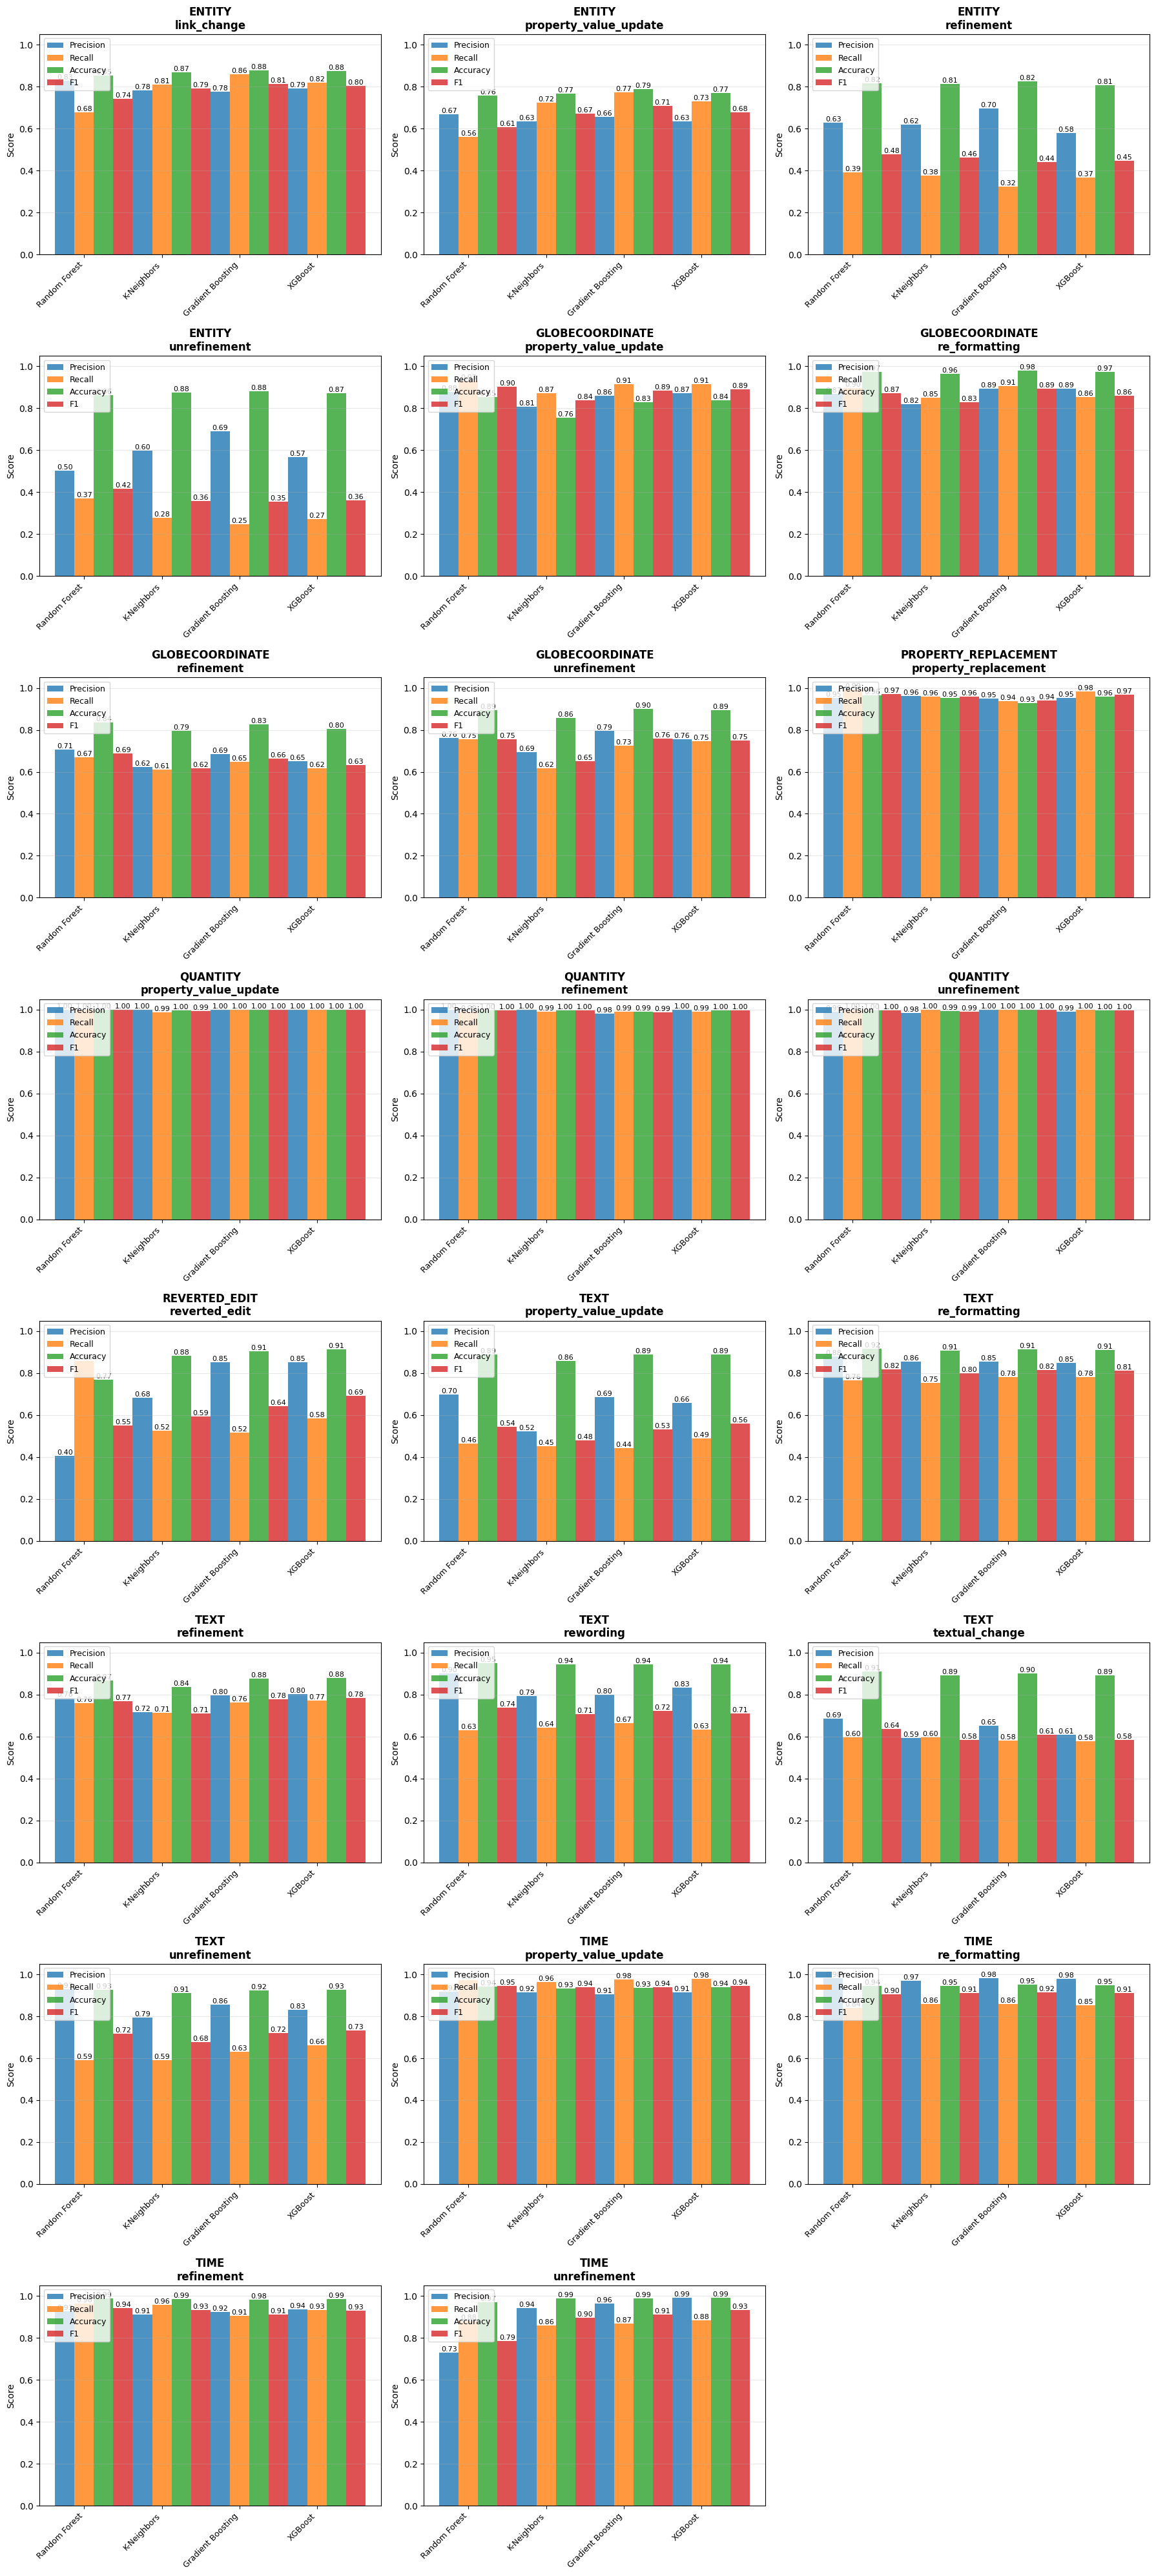

,datatype,label,best_model,best_f1,best_recall,best_precision
0,globecoordinate,property_value_update,random_forest,0.902309,0.930612,0.876861
1,globecoordinate,re_formatting,gradient_boosting,0.893732,0.905000,0.894615
2,globecoordinate,refinement,random_forest,0.686780,0.670846,0.707081
3,globecoordinate,unrefinement,gradient_boosting,0.757643,0.754483,0.794081
4,quantity,property_value_update,random_forest,1.000000,1.000000,1.000000
5,quantity,refinement,kn,0.995349,0.990909,1.000000
6,quantity,unrefinement,gradient_boosting,1.000000,1.000000,1.000000
7,time,property_value_update,random_forest,0.945376,0.978144,0.918707
8,time,re_formatting,gradient_boosting,0.915691,0.858105,0.983015
9,time,refinement,random_forest,0.941692,0.962511,0.936174


Overall best model:
Model: kn, Score: 1
Model: random_forest, Score: 11
Model: gradient_boosting, Score: 6
Model: xgboost, Score: 5
Overall best model is random_forest with score 11/ 23


In [105]:

import pandas as pd

models = ['random_forest', 'kn', 'gradient_boosting', 'xgboost']
model_labels = ['Random Forest', 'K-Neighbors', 'Gradient Boosting', 'XGBoost']
metrics = ['precision', 'recall', 'accuracy', 'f1']

# Count subplots
total_plots = sum(len(results_dt_label_model[dt]) for dt in results_dt_label_model)
ncols = 3
nrows = (total_plots + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(18, 5*nrows))
if isinstance(axes, np.ndarray):
    axes = axes.flatten()
else:
    axes = [axes]

plot_idx = 0
for datatype in sorted(results_dt_label_model.keys()):
    for label in sorted(results_dt_label_model[datatype].keys()):
        ax = axes[plot_idx]
        
        x = np.arange(len(models))
        width = 0.25
        
        for i, metric in enumerate(metrics):
            values = [results_dt_label_model[datatype][label][model][metric] for model in models] # metric (accuracy/precision/recall/f1) values for this label and datatype
            
            offset = (i - 1) * width
            bars = ax.bar(x + offset, values, width, label=metric.capitalize(), alpha=0.8)
            
            for bar in bars:
                height = bar.get_height()
                ax.text(bar.get_x() + bar.get_width()/2., height,
                       f'{height:.2f}',
                       ha='center', va='bottom', fontsize=8)
        
        ax.set_ylabel('Score')
        ax.set_title(f'{datatype.upper()}\n{label}', fontweight='bold', fontsize=12)
        ax.set_xticks(x)
        ax.set_xticklabels(model_labels, rotation=45, ha='right', fontsize=9)
        ax.legend(loc='upper left', fontsize=9)
        ax.grid(axis='y', alpha=0.3)
        ax.set_ylim([0, 1.05])
        
        plot_idx += 1

for idx in range(plot_idx, len(axes)):
    axes[idx].set_visible(False)

plt.tight_layout()
plt.savefig('classifier_metrics_all.png', dpi=300, bbox_inches='tight')
plt.show()

# OVERALL: the best one seems to be gradient boosting, in some cases (not many) random forest does better


score_per_model = {}
df_data = {
    'datatype': [],
    'label': [],
    'best_model': [],
    'best_f1': [],
    'best_recall': [],
    'best_precision': []
}
for datatype in results_dt_label_model:
    for label in results_dt_label_model[datatype]:
        best_model = None
        best_f1 = 0
        best_recall = 0
        best_precision = 0
        for model in results_dt_label_model[datatype][label]:
            if model not in score_per_model:
                score_per_model[model] = 0
            f1 = results_dt_label_model[datatype][label][model]['f1']
            recall = results_dt_label_model[datatype][label][model]['recall']
            precision = results_dt_label_model[datatype][label][model]['precision']
            if f1 > best_f1:
                best_f1 = f1
                best_model = model

            if recall > best_recall:
                best_recall = recall
            
            if precision > best_precision:
                best_precision = precision

        df_data['datatype'].append(datatype)
        df_data['label'].append(label)
        df_data['best_model'].append(best_model)
        df_data['best_f1'].append(best_f1)
        df_data['best_recall'].append(best_recall)
        df_data['best_precision'].append(best_precision)
        score_per_model[best_model] += 1

df = pd.DataFrame(df_data)
display(df)

print('Overall best model:')

best_score = 0
best_model = None
for model, score in score_per_model.items():
    if score > best_score:
        best_score = score
        best_model = model
    print(f'Model: {model}, Score: {score}')

print(f'Overall best model is {best_model} with score {best_score}/ {sum(score_per_model.values())}')

In [ ]:
# TODO: save this analysis somewhere + plots
# have to add more features.... :(

import shap
from sklearn.preprocessing import MultiLabelBinarizer

with open('classifiers_multilabel_random_forest.pkl', 'rb') as f:
    classifiers = pickle.load(f)
    
results_fold_0 = classifiers['text'][0]  # Example for 'string' datatype
model = results_fold_0['model']
test_index = results_fold_0['test_index']

datatype = 'text'  
df_type = pd.read_csv(f'features/gs_features_{datatype}.csv')
df_test = df_type.loc[test_index].copy()

with open('features/feature_cols_text.pkl', 'rb') as f:
    feature_cols = pickle.load(f)

explainer = shap.TreeExplainer(model)
X_test = df_test[feature_cols].copy()
shap_values = explainer(X_test) # Computes SHAP values for the test data to explain predictions.

# from the doc: classes_ndarray of shape (n_classes,) or a list of such arrays
# The classes labels (single output problem), or a list of arrays of class labels (multi-output problem)
print(f'Models classes_: {model.classes_}') # [array([0, 1]), array([0, 1]), array([0, 1]), array([0, 1]), array([0, 1]), array([0, 1])]
print(f'Feature importances: {model.feature_importances_}')
print(shap_values.shape) # (206, 14, 12)
# 14 features
# 206 examples
# 12 -> negative_class_0, positive_class_0, negative_class_1, positive_class_1, ..., negative_class_5, positive_class_5

# label_binarizer = results_fold_0['multi_label_binarizer']
# for idx, label in enumerate(label_binarizer.classes_):
#     print(label)
#     print('Shap values shape:', shap_values.shape) # (206, 14, 12)
#     shap.summary_plot(shap_values[:, :, idx*2+1], X_test) # im getting all rows, all features, positive class only

# each dot represents a SHAP value for a featura and an instance. the color indicates the feature value (high or low)
# you see how each feature importance varies across the dataset
# Features are ordered by importance from TOP to BOTTOM - the feature at the top is the most important

# Positive SHAP -> pushes prediction toward class 1 (positive)
# Negative SHAP -> pushes prediction toward class 0 (negative)

# Examples of how to read this plots:
# Feature at top, red dots on right side: "High values of this feature strongly predict positive class"
# Feature at top, blue dots on left side: "Low values of this feature strongly predict negative class"


# Across classes the features punct_differs, case_differs, brackets_differs, hyph_dash_differs are all crumpled around 0
# they don't influence much the predictions...

for feat in ['spaces_differs', 'case_differs', 'punct_differs', 'hyph_dash_differs', 'brackets_differs']:
    print(f"\n{feat}:")
    print(f"  Mean: {df_type[feat].mean():.4f}")
    print(f"  Std: {df_type[feat].std():.4f}")
    print(f"  % zeros: {(df_type[feat] == 0).mean()*100:.1f}%")
    print(f"  Value counts:\n{df_type[feat].value_counts()}")

Models classes_: [array([0, 1]), array([0, 1]), array([0, 1]), array([0, 1]), array([0, 1]), array([0, 1])]
Feature importances: [0.17548179 0.12735916 0.00278607 0.08377677 0.10633102 0.11651543
 0.01798157 0.0403236  0.18097114 0.00612893 0.00600888 0.00032756
 0.00050926 0.13549882]
(206, 14, 12)

spaces_differs:
  Mean: 0.0398
  Std: 0.1957
  % zeros: 96.0%
  Value counts:
spaces_differs
0    988
1     41
Name: count, dtype: int64

case_differs:
  Mean: 0.0437
  Std: 0.2046
  % zeros: 95.6%
  Value counts:
case_differs
0    984
1     45
Name: count, dtype: int64

punct_differs:
  Mean: 0.0107
  Std: 0.1029
  % zeros: 98.9%
  Value counts:
punct_differs
0    1018
1      11
Name: count, dtype: int64

hyph_dash_differs:
  Mean: 0.0019
  Std: 0.0441
  % zeros: 99.8%
  Value counts:
hyph_dash_differs
0    1027
1       2
Name: count, dtype: int64

brackets_differs:
  Mean: 0.0019
  Std: 0.0441
  % zeros: 99.8%
  Value counts:
brackets_differs
0    1027
1       2
Name: count, dtype: int64

In [169]:
from sklearn.preprocessing import MultiLabelBinarizer

df = pd.read_csv('gold_standard/gold_standard.csv')

# this is wrong because it could be doing the binasrization differently
df['labels_list'] = df['label'].str.split(', ')

all_labels = [label for labels in df['labels_list'] for label in labels]

label_binarizer = MultiLabelBinarizer()
y_binary = label_binarizer.fit_transform(df['labels_list'])

y_df = pd.DataFrame(y_binary, columns=label_binarizer.classes_)

# df with binary columns for each label
df = pd.concat([df, y_df], axis=1)
df.drop(columns=['labels_list'], inplace=True)
df.head(50) 

WD_STRING_TYPES = ['monolingualtext', 'string', 'external-id', 'url', 'commonsMedia', 'geo-shape', 'tabular-data', 'math', 'musical-notation', 'unknown-values']
WD_ENTITY_TYPES = ['wikibase-item', 'wikibase-entityid', 'wikibase-property', 'wikibase-lexeme', 'wikibase-sense', 'wikibase-form', 'entity-schema']
WD_BASIC_TYPES = ['globecoordinate', 'quantity', 'time']

df['new_datatype'] = df.apply(
    lambda x: 'text' if x['datatype'] in WD_STRING_TYPES else ('entity' if x['datatype'] in WD_ENTITY_TYPES else x['datatype']), axis=1
)
label_columns = label_binarizer.classes_.tolist()
label_distribution = df.groupby('new_datatype')[label_columns].sum()
# display(label_distribution)

# TODO: Label untill 200 changes
# Entity: more unrefinemet
# Globe: more re-formatting, refinemet and unrefinement
# Quantity; more re-formatting, refinemet and unrefinement
# Text: more porp value update, textual change, rewording and unrefinement
# Time: more refinement and unrefinement

# TODO:
# features correlate with the labels
# see feature importance for the ones that don't perform that well


# get predictions

with open('classifiers_multilabel_random_forest.pkl', 'rb') as f:
    classifiers = pickle.load(f)

datatype = 'text'
results_fold_0 = classifiers[datatype][0]
# for result_f in results_folds:
model = results_fold_0['classifier']
multi_label_binarizer = results_fold_0['multi_label_binarizer']
y_pred = results_fold_0['y_pred']
y_test = results_fold_0['y_test']
test_index = results_fold_0['test_index']

y_pred_labels = multi_label_binarizer.inverse_transform(y_pred)
y_test_labels = multi_label_binarizer.inverse_transform(y_test)

pred_df = pd.DataFrame({
    'predicted_labels': [', '.join(labels) if labels else '(none)' for labels in y_pred_labels],
    'true_labels': [', '.join(labels) if labels else '(none)' for labels in y_test_labels]
})

# If you have test_indices, you can merge back to original df

pred_df['original_index'] = test_index
df_type = pd.read_csv(f'features/gs_features_{datatype}.csv')
df_with_predictions = df_type.loc[test_index].copy()
df_with_predictions['predicted_labels'] = pred_df['predicted_labels'].values

display(df_with_predictions[['old_value', 'new_value', 'label', 'predicted_labels']].head(20))

,old_value,new_value,label,predicted_labels
2,"""video game""","""2021 video game""",refinement,refinement
3,"""Avianca Logo 2013.png""","""Logo avianca.png""","unrefinement, rewording",rewording
10,"""Coming Home (2012 film)""","""Coming Home""",unrefinement,unrefinement
23,"""Kim Dong-Jin""","""Kim Dong-jin""",re_formatting,re_formatting
25,"""0000 0001 1450 1058""","""0000000114501058""",re_formatting,re_formatting
30,"""tower block""","""commercial skyscraper in London""",refinement,property_value_update
31,"""human""","""german politician""",refinement,refinement
39,"""American singer-songwriter""","""American singer""",unrefinement,unrefinement
44,"""LTV A-7 Corsair II""","""A-7 Corsair II""",unrefinement,(none)
54,"""parrot""","""Psittaciformes""",property_value_update,(none)


In [68]:
pred_label_counts = [len(labels) for labels in y_pred_labels]
true_label_counts = [len(labels) for labels in y_test_labels]

print("Predicted labels per sample:")
print(pd.Series(pred_label_counts).value_counts().sort_index())

print("\nTrue labels per sample:")
print(pd.Series(true_label_counts).value_counts().sort_index())

Predicted labels per sample:
0     40
1    153
2     13
Name: count, dtype: int64

True labels per sample:
1    196
2     10
Name: count, dtype: int64
